In [1]:
from helper import *
import pytensor.tensor as pt
from pytensor import function
import warnings
warnings.filterwarnings('ignore')

### （1）Read Data and Summary（10分）

请读取数据，分别统计学习阶段和测验阶段中，各复合刺激出现的次数、各复合刺激下动物获得奖赏的概率、以及各复合刺激下动物的平均啄食次数。

In [2]:
df = pd.read_csv('data.csv')
print(f'数据维度: {df.shape}')
print(f'列名: {list(df.columns)}')
df.head()


数据维度: (400, 12)
列名: ['Phase', 'Stimulus', 'Light_A', 'Light_B', 'Sound_X', 'Sound_Y', 'Stim_AX', 'Stim_AY', 'Stim_BX', 'Stim_BY', 'Reward', 'Action']


,Phase,Stimulus,Light_A,Light_B,Sound_X,Sound_Y,Stim_AX,Stim_AY,Stim_BX,Stim_BY,Reward,Action
0,Learning,AX,1,0,1,0,1,0,0,0,0,4
1,Learning,BX,0,1,1,0,0,0,1,0,1,4
2,Learning,AY,1,0,0,1,0,1,0,0,1,5
3,Learning,AX,1,0,1,0,1,0,0,0,1,3
4,Learning,AX,1,0,1,0,1,0,0,0,0,6


In [3]:
df.groupby(['Phase', 'Stimulus']).agg({'Stimulus': 'count', 'Reward': 'mean', 'Action': 'mean'}).round(3)

Stimulus  Reward  Action
Phase    Stimulus                          
Learning AX             120   0.208   3.200
         AY             120   0.508   3.258
         BX             120   0.583   3.675
Test     AX              10   0.300   2.500
         AY              10   0.600   4.100
         BX              10   0.800   4.600
         BY              10   1.000   4.100

**观察**：
- 学习阶段仅出现 AX、AY、BX 三种复合刺激
- BY 复合刺激只在测验阶段出现
- 奖赏概率：AX ≈ 21%，AY ≈ 51%，BX ≈ 58%；测验阶段 BY = 100%。

### （2）Simulation for RW Model（10分）

【绘图】请分别模拟“特征RW模型”与“组合RW模型”中联结强度随试次的更新过程并绘图

【文字解答】请比较两个模型对刺激联结强度的预测有何差异。

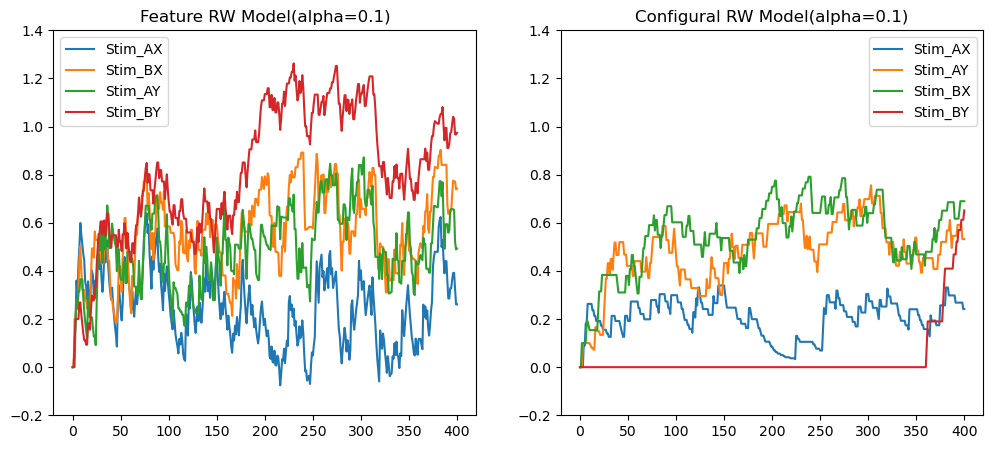

In [4]:
FeatureRW = LearningAgent(FeaturalModel())
ConfiguralRW = LearningAgent(ConfiguralModel())

def feature_to_configural(feature_weights):
    return pd.DataFrame({
        'Stim_AX': feature_weights['Light_A'] + feature_weights['Sound_X'],
        'Stim_BX': feature_weights['Light_B'] + feature_weights['Sound_X'],
        'Stim_AY': feature_weights['Light_A'] + feature_weights['Sound_Y'],
        'Stim_BY': feature_weights['Light_B'] + feature_weights['Sound_Y']
    })

def RW_prediction_compare(alpha):
    FeatureRW.run_trial(df, alpha = alpha)
    weight_rw_feature = FeatureRW.get_weight_history()
    ConfiguralRW.run_trial(df, alpha = alpha)
    weight_rw_configural = ConfiguralRW.get_weight_history()
    
    _, ax = plt.subplots(1, 2, figsize = (12, 5))
    weight_rw_feature.plot(title=f'Feature RW Model(alpha={alpha})', ax = ax[0])
    weight_rw_configural.plot(title=f'Configural RW Model(alpha={alpha})', ax = ax[1])
    [ax[i].set_ylim((-0.2, 1.4)) for i in range(2)]
    plt.show()

RW_prediction_compare(alpha = 0.1)
# 组合RW模型无法更新BY的联结强度，而特征RW模型单个试次更新的波动更强

**两个模型的差异:**
- 组合 RW 无法更新 $\omega_{BY}$, 但是 特征 RW 模型可以 通过 $\omega_B$ 和 $\omega_Y$ 间接更新
- 当学习率 $\alpha$ 和 预测误差 $\delta$ 均相等时, 特征 RW 模型对两个特征分别进行更新，而组合 RW 模型只对组合进行一次更新，前者前期更快接近真实的奖赏概率，但是后期波动性也更强.

### （3）Simulation Frequency Model（10分）

【绘图】请分别模拟“特征频率模型”与“组合频率模型”中联结强度随试次的更新过程并绘图，要求同Q2。

【文字解答】请对比频率模型和RW模型的模拟结果，比较二者联结强度变化趋势上的异同。

【文字解答】请尝试解释在“特征频率模型”中为何总联结强度要计算均值而非总和。

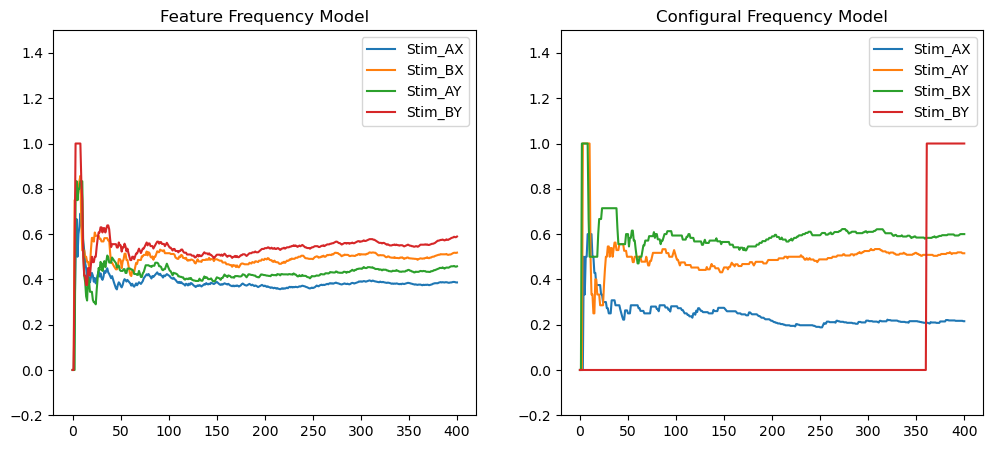

In [5]:
FeatureFreq = StatisticalAgent(FeaturalModel())
ConfiguralFreq = StatisticalAgent(ConfiguralModel())

def Freq_prediction_compare():
    FeatureFreq.run_trial(df)
    weight_freq_feature = FeatureFreq.get_weight_history()
    ConfiguralFreq.run_trial(df)
    weight_freq_configural = ConfiguralFreq.get_weight_history()
    _, ax = plt.subplots(1, 2, figsize = (12, 5))
    weight_freq_feature.plot(title='Feature Frequency Model', ax = ax[0])
    weight_freq_configural.plot(title='Configural Frequency Model', ax = ax[1])
    [ax[i].set_ylim((-0.2, 1.5)) for i in range(2)]
    plt.show()

Freq_prediction_compare()
# Freq 对比 RW，学习率先快后慢，前期过于迅速，后期过于稳定

**变化趋势异同**
- 相比RW模型，频率模型更新速率快噪声大，后期更新速率慢噪声小，可以看作学习率逐步下降的 $\delta$ 规则更新. $$\omega^{(t+1)} = \omega^{(t)} + \frac{1}{1+t} \delta^{(t+1)}$$
- 所有模型最终收敛到真实奖赏频率, 但是随着试次数增加，频率模型最终精确地收到真实奖赏概率（大数定律），而 RW 模型不具有这个性质

**为什么特征频率模型不能直接求和**
- 组合频率模型直接估计 $P(R|AX), P(R|AY), P(R|BX), P(R|BY)$, 在前三个情况下表现良好，但是在第四个情况下无法工作, 因为从来没有出现过 $BY$
- 特征频率模型则直接估计 $P(R|A), P(R|B), P(R|X), P(R|Y)$，我们关心的问题就是如何用 $P(R|B)$ 和 $P(R|Y)$ 估计 $P(R|BY)$
- 直接相加是荒谬的，从$P(R|B) = 0.6, P(R|Y) = 0.7$不能得到 $P(P|BY) = 1.3$
- 但是求平均也是没什么道理的, 但至少没那么荒谬

**应该如何计算呢?**
- 首先我们引入对数几率(logit odds)轴代替概率(probability)轴表征概率 $$\lambda(x) = \log\frac{P(x)}{1-P(x)}$$
- 然后定义证据 E (可以是A, B, X, Y或者他们的组合) 对预测奖赏的贡献$$L(E) = \lambda(R|E) - \lambda(R)$$ 其中 $P(R|E)$ 是我们可以用经验数据去估计的，而 $P(R)$ 是奖赏出现的基础比率; 
- 在条件独立性假设(数学定义是 $P(BY|R) = P(B|R)P(Y|R)$，就是B, Y两个因素独立的预测 R)下，$L(BY) = L(B)+L(Y)$, 这里的证据 L 是可以累加的，详细证明过程可以了解朴素贝叶斯分类器和贝叶斯证据累积;
- 如果我们假设 $P(R)=0.5$, 在 $P(R|B) = 0.6, P(R|Y) = 0.7$ 的例子中我们会给出 $P(R|BY)=7/9$ 的估计，即两个预测奖赏出现的刺激之间发生了累加；而如果$P(R|B) = 0.3, P(R|Y) = 0.7$ 的结果是 $P(R|BY)=1/2$, 预测和阻碍奖赏出现的刺激进行了平均

**为什么RW模型就可以直接加**
- 频率模型明确地将联结强度定义为条件概率
- RW 的模型中并没有语义上定义联结强度 $\omega$ 是什么, 我们可以假定 RW 模型就是在学习证据 $L$, 所以有可加性
- 最后，以上仅作为理论推导，人类大脑是如何整合证据的，依旧是有待进一步探索的问题.




### （4）MLE Model Fitting（20分）

【文字解答】结合课程所学知识与本题实验背景，说明你对各参数的**初始值**与**边界条件**的设置依据。解释你是如何避免 $b + V$ 出现非正值的。

【结果报告】请报告你拟合得到的参数值。


In [6]:
def nll_learning(theta, agent, data):
    alpha, b = theta
    return -agent.loglikelihood(data, b=b, alpha=alpha)
def nll_statistical(theta, agent, data):
    b = theta[0]
    return -agent.loglikelihood(data, b=b)

In [7]:
def mle_fit_statistical(agent, N_random=3):
    res_record = []
    for _ in range(N_random):
        b0 = np.random.uniform(0.0, 10.0)
        res = minimize(nll_statistical, x0=[b0], args=(agent, df), bounds=[(1.0, 10.0)])
        res_record.append(res)
    res_record.sort(key=lambda x: x.fun)
    return res_record[0]

def mle_fit_learning(agent, N_random=3):
    res_record = []
    for _ in range(N_random):
        alpha0 = np.random.uniform(0.0, 1.0)
        b0 = np.random.uniform(0.0, 10.0)
        res = minimize(nll_learning, x0=[alpha0, b0], args=(agent, df), bounds=[(0.0, 1.0), (1.0, 10.0)])
        res_record.append(res)
    res_record.sort(key=lambda x: x.fun)
    return res_record[0]

# alpha在[0,1]之间是theory驱动的，0表示完全不更新，1表示完全无记忆
# b在[0, 10]之间, Action均值在2-4之间，也可以选大于0的下界防止出问题
# x0在范围内随机选择N_random次，事实上N_random不需要很大


In [8]:
record = {}
res_FeatureRW = mle_fit_learning(FeatureRW)
record['FeatureRW'] = {'alpha': res_FeatureRW.x[0], 'b': res_FeatureRW.x[1], 'nll': res_FeatureRW.fun, 'nparams': 2}
res_ConfiguralRW = mle_fit_learning(ConfiguralRW)
record['ConfiguralRW'] = {'alpha': res_ConfiguralRW.x[0], 'b': res_ConfiguralRW.x[1], 'nll': res_ConfiguralRW.fun, 'nparams': 2}
res_FeatureFreq = mle_fit_statistical(FeatureFreq)
record['FeatureFreq'] = {'alpha': np.nan, 'b': res_FeatureFreq.x[0], 'nll': res_FeatureFreq.fun, 'nparams': 1}
res_ConfiguralFreq = mle_fit_statistical(ConfiguralFreq)
record['ConfiguralFreq'] = {'alpha': np.nan, 'b': res_ConfiguralFreq.x[0], 'nll': res_ConfiguralFreq.fun, 'nparams': 1}

**参数初始值**
- $\alpha \sim U(0, 1)$, 0表示完全不学习，1表示完全无记忆
- 理论上$b\in(0, \infty)$, 但这这里从 $b\sim U(0, 10)$ 采样初始值, 因为数据统计中的 Action 均值就是在2-4之间

**如何避免 b+V 出现非正数的**
- 为什么不应该出现，语义上b+V是啄食次数的期望，数学上泊松分布的PMF是$$P(X=k) = \frac{(b+V)^k}{k!}e^{-(b+V)}$$, 负的期望会导致负的概率, 而0的期望会导致在 X=0 以外概率质量都是 0, 都会导致计算对数似然时报错
- 如何避免，计算 b+V 后强制取 max(·, 10^-8)

### （5）MLE Model Comparison（10分）

【文字解答】请说明你认为哪种方法最适用于本题的模型比较情境，并解释理由。

【结果报告】使用你选择的方法，进行模型比较，选出四个模型中的最优模型。

In [9]:
record_df = pd.DataFrame(record).T
record_df['AIC'] = 2 * record_df['nll'] + 2 * record_df['nparams']
record_df['BIC'] = 2 * record_df['nll'] + np.log(len(df)) * record_df['nparams']
record_df
# 显然模型不是嵌套模型，同时CV不太好用是因为试次的顺序比较重要
# AIC和BIC的结论是一致的，FeatureRW是解释数据表现最好的模型

,alpha,b,nll,nparams,AIC,BIC
FeatureRW,0.384547,2.960954,807.266882,2.0,1618.533765,1626.516694
ConfiguralRW,0.859217,2.966400,807.400688,2.0,1618.801377,1626.784306
FeatureFreq,NaN,2.979332,819.112687,1.0,1640.225374,1644.216839
ConfiguralFreq,NaN,2.972149,818.570072,1.0,1639.140144,1643.131609


**比较方式选择**
- 使用AIC/BIC对全部400个试次的拟合效果进行比较是合理的方式
- 将前面 360 个试次作为训练集 学习参数，用后面 40 个试次作为测试集，检查比较 40个试次的对数似然，似乎也不是不行

### （6）MCMC fitting（20分）

【绘图】请使用`pymc`中的`model_to_graphviz()`或`model_to_networkx()`绘制概率模型图

【绘图与结果报告】各参数后验分布的均值及 95% 最高密度区间（HDI）。

【文字解答】请评估MC链的收敛情况。

In [10]:
actions = pt.as_tensor(df['Action'].values)  # 读取Observation

with pm.Model() as model:
    # Parameter Prior
    alpha = pm.Uniform('alpha', lower=0.0, upper = 1.0)
    b = pm.Uniform('b', lower=0.01, upper = 10)

    # Predict V using the FeatureRW model (pytensor based)
    pred_V = FeatureRW.predict_V_pt(df, alpha = alpha)

    # Predict V -> Predict N -> Predict Action -> Likelihood
    lamb = pm.Deterministic('lambda', 1.0 * pred_V + b)
    obs = pm.Poisson('obs', mu=lamb, observed=actions)

    # Sampling
    trace = pm.sample(1000, tune=1000, return_inferencedata=True)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 107 seconds.


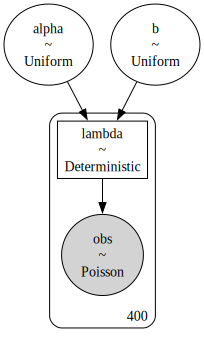

In [11]:
model.to_graphviz()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.381,0.085,0.216,0.537,0.001,0.001,3859.0,2798.0,1.0
b,2.969,0.093,2.796,3.147,0.002,0.001,3518.0,2902.0,1.0


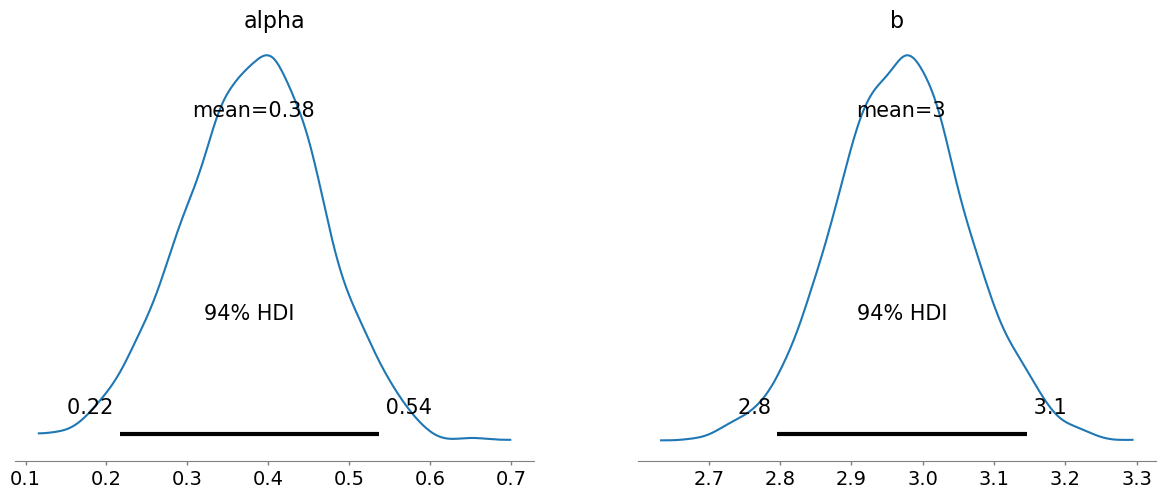

In [12]:
az.plot_posterior(trace, var_names=['alpha', 'b'])
pm.summary(trace, var_names=['alpha', 'b'])

# alpha, posterior mean 0.309, hdi [0.196, 0.420], r_hat = 1.00 (good fit)
# b, posterior mean 1.999, hid [1.843, 2.131], r_hat = 1.00 (good fit)


**收敛性评估**
- 主要看R hat = 1.00, 说明各链收敛到相同的后验分布
- 有效样本量 ESS 也可以作为辅助证据

### Prior Makes a Difference（7）（10分）

【绘图】请比较两种先验下 $b$ 与 $\alpha$ 的后验分布。

【文字解答】$b$ 的先验选择是否影响 $\alpha$ 的后验分布？

In [13]:
actions = pt.as_tensor(df['Action'].values)
with pm.Model() as model_smallb:
    alpha = pm.Uniform('alpha', lower=0.0, upper = 1.0)
    b = pm.Normal('b', mu = 1.0, sigma = 0.1)
    pred_V = FeatureRW.predict_V_pt(df, alpha = alpha)
    lamb = pm.Deterministic('lambda', 1.0 * pred_V + b)
    obs = pm.Poisson('obs', mu=lamb, observed=actions)
    trace_smallb = pm.sample(1000, tune=1000, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 87 seconds.


In [14]:
actions = pt.as_tensor(df['Action'].values)
with pm.Model() as model_largeb:
    alpha = pm.Uniform('alpha', lower=0.0, upper = 1.0)
    b = pm.Normal('b', mu = 4.0, sigma = 0.2)
    pred_V = FeatureRW.predict_V_pt(df, alpha = alpha)
    lamb = pm.Deterministic('lambda', 1.0 * pred_V + b)
    obs = pm.Poisson('obs', mu=lamb, observed=actions)
    trace_largeb = pm.sample(1000, tune=1000, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 90 seconds.


In [15]:
az.summary(trace_largeb, var_names=['alpha', 'b'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.394,0.090,0.237,0.565,0.002,0.001,3549.0,2820.0,1.0
b,3.155,0.085,3.000,3.315,0.002,0.001,3026.0,2481.0,1.0


In [16]:
az.summary(trace_smallb, var_names=['alpha', 'b'])
# 直接影响是 b 的后验分布，alpha 的后验分布受 b 的影响较大，b 越大，alpha 的后验分布越偏向于较小的值（类似代偿）

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.324,0.067,0.202,0.451,0.001,0.001,3765.0,2770.0,1.0
b,2.189,0.057,2.088,2.304,0.001,0.001,3888.0,2732.0,1.0


<Axes: title={'center': 'b'}>

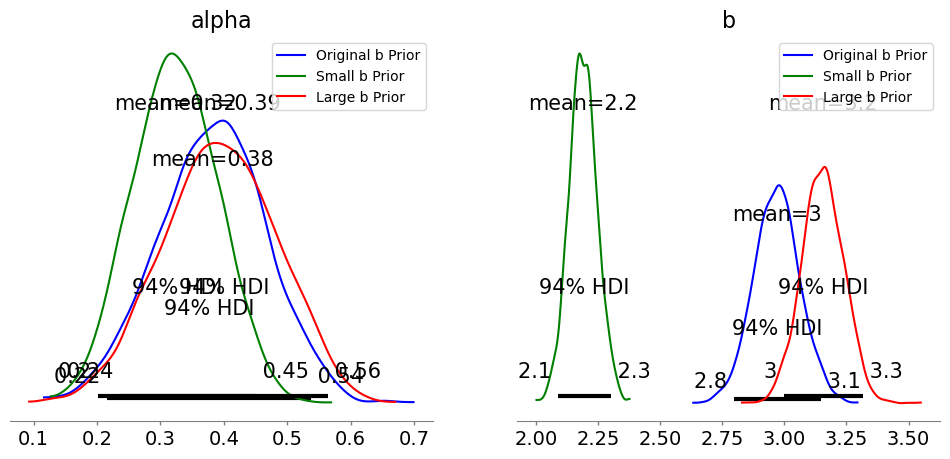

In [17]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))

az.plot_posterior(trace, var_names=['alpha'], ax = ax[0], color = 'blue', label = ['Original b Prior'])
az.plot_posterior(trace_smallb, var_names=['alpha'], ax = ax[0], color = 'green', label = ['Small b Prior'])
az.plot_posterior(trace_largeb, var_names=['alpha'], ax = ax[0], color = 'red', label = ['Large b Prior'])

az.plot_posterior(trace, var_names=['b'], ax = ax[1], color = 'blue', label = ['Original b Prior'])
az.plot_posterior(trace_smallb, var_names=['b'], ax = ax[1], color = 'green', label = ['Small b Prior'])
az.plot_posterior(trace_largeb, var_names=['b'], ax = ax[1], color = 'red', label = ['Large b Prior'])

# large b prior -> large b posterior -> large alpha posterior (surprise)

# 以下未完成

In [ ]:
# 另一个模型Feature-based Frequency模型
actions = pt.as_tensor(df['Action'].values)
with pm.Model() as model:
    b = pm.Uniform('b', lower=0.0, upper = 10.0)
    pred_V = FeatureFreq.predict_V_pt(df)
    lamb = pm.Deterministic('lambda', 1.0 * pred_V + b)
    obs = pm.Poisson('obs', mu=lamb, observed=actions)
    trace = pm.sample(1000, tune=1000, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 21 seconds.


In [ ]:

actions = pt.as_tensor(df['Action'].values)
with pm.Model() as model:
    b = pm.Normal('b', mu=4.0, sigma=0.2)
    pred_V = FeatureFreq.predict_V_pt(df)
    lamb = pm.Deterministic('lambda', 1.0 * pred_V + b)
    obs = pm.Poisson('obs', mu=lamb, observed=actions)
    trace_largeb = pm.sample(1000, tune=1000, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


In [ ]:
actions = pt.as_tensor(df['Action'].values)
with pm.Model() as model:
    b = pm.Normal('b', mu=1.0, sigma=0.1)
    pred_V = FeatureFreq.predict_V_pt(df)
    lamb = pm.Deterministic('lambda', 1.0 * pred_V + b)
    obs = pm.Poisson('obs', mu=lamb, observed=actions)
    trace_smallb = pm.sample(1000, tune=1000, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


<Axes: title={'center': 'b'}>

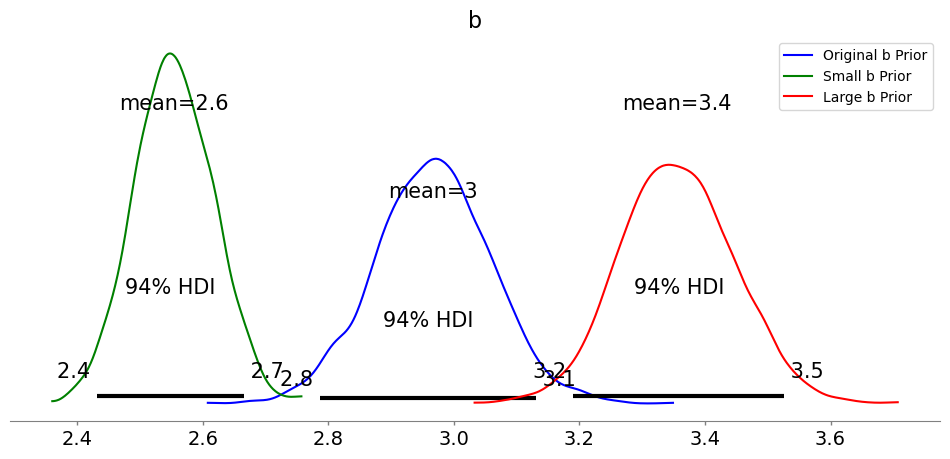

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (12, 5))

az.plot_posterior(trace, var_names=['b'], ax = ax, color = 'blue', label = ['Original b Prior'])
az.plot_posterior(trace_smallb, var_names=['b'], ax = ax, color = 'green', label = ['Small b Prior'])
az.plot_posterior(trace_largeb, var_names=['b'], ax = ax, color = 'red', label = ['Large b Prior'])

# large b prior -> large b posterior -> large alpha posterior (surprise)